# Lightweight ASL Alphabet Recognition (A-Z) - Training Notebook

This notebook trains a **lightweight sign-language alphabet recognizer** for all 26 letters: **A through Z**.

It uses **MediaPipe hand landmarks** + a compact sequence model, which is ideal for:
- Fast training on the alphabet dataset
- Low-latency real-time inference on webcams
- Comprehensive performance metrics for model evaluation

## Dataset Setup for Alphabet (A-Z)

This notebook is configured to train on all 26 alphabet letters:
- `A`, `B`, `C`, ... `Z`

Your dataset structure should be:
- `dataset/A/`, `dataset/B/`, ..., `dataset/Z/` with images or videos

It can read from either:
1. **Video files** (`.avi`, `.mp4`, etc.)
2. **Frame folders** (clip folders containing images)

Default is to use **videos** when present (recommended for cleaner temporal learning).
All alphabet folders in the dataset will be automatically included.

In [4]:
# Dependency setup
!pip -q uninstall -y mediapipe mediapipe-silicon mediapipe-nightly
!pip -q install --no-cache-dir "protobuf<5" "mediapipe==0.10.14" "opencv-python-headless<4.11" scikit-learn==1.5.1

print(
    "✅ Dependencies installed. If this is a fresh install, restart kernel before running next cells."
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 287.4 MB/s eta 0:00:00a 0:00:01
✅ Dependencies installed. If this is a fresh install, restart kernel before running next cells.


In [5]:
import os
import warnings

# Reduce verbose native logs from TensorFlow/MediaPipe
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import cv2
import json
import random
import numpy as np
import pandas as pd
from glob import glob

import mediapipe as mp
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# Hide known noisy protobuf deprecation warning
warnings.filterwarnings(
    "ignore",
    message=r"SymbolDatabase.GetPrototype\(\) is deprecated.*",
    category=UserWarning,
    module="google.protobuf.symbol_database",
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("MediaPipe version:", getattr(mp, "__version__", "unknown"))
print("MediaPipe path:", getattr(mp, "__file__", "<namespace>"))

if not hasattr(mp, "solutions"):
    raise RuntimeError(
        "Loaded mediapipe does not expose mp.solutions. This usually means a conflicting package/module. "
        "Re-run Cell 3, restart kernel, then re-run from Cell 4."
    )

2026-05-25 11:11:18.178193: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779707478.575790      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779707478.691633      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779707479.682719      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779707479.682777      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779707479.682780      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
MediaPipe version: 0.10.14
MediaPipe path: /usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py


In [6]:
import requests, zipfile, io

url = "https://data.mendeley.com/public-api/zip/8fmvr9m98w/download/3"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("/kaggle/working/signalphaset")

In [7]:
!unzip -q /kaggle/working/signalphaset/SignAlphaSet/ASL_dynamic.zip

In [8]:
# =========================
# Configuration
# =========================
DATA_ROOT = "/kaggle/working/ASL_dynamic"  # Point this to your dataset root if needed
VIDEO_EXTS = (".mp4", ".avi", ".mov", ".mkv", ".webm")
FRAME_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# Alphabet: all 26 letters
TARGET_LETTERS = [chr(ord('A') + i) for i in range(26)]  # A-Z
REQUIRE_ALL_TARGET_LETTERS = False  # Set to True if you want all 26 letters

# Choose source type: "video", "frames", or "auto"
# - video: use clips only
# - frames: use frame folders only
# - auto: prefer videos if found, otherwise frames
PREFERRED_SOURCE = "frames"  # Changed to frames as typical for alphabet datasets

MAX_FRAMES = 40  # Number of timesteps per sample
MAX_SAMPLES_PER_CLASS = 500  # Safety cap for speed/memory
IMG_SIZE = (320, 240)
TEST_SIZE = 0.15
VAL_SIZE = 0.15
BATCH_SIZE = 16  # Larger batch size for more classes
EPOCHS = 50

CACHE_DIR = "/kaggle/working/cache_landmarks_alphabet"
os.makedirs(CACHE_DIR, exist_ok=True)

print("Config ready.")

Config ready.


In [9]:
import re


def normalize_token(s: str) -> str:
    s = s.strip().upper()  # Changed to upper for letters
    s = re.sub(r"[^A-Z0-9]", "", s)
    return s


TARGET_MAP = {normalize_token(w): w for w in TARGET_LETTERS}


def infer_label_from_path(path: str):
    parts = os.path.normpath(path).split(os.sep)
    for p in reversed(parts):
        t = normalize_token(p)
        if t in TARGET_MAP:
            return TARGET_MAP[t]
    return None


def discover_video_files(data_root):
    files = []
    for ext in VIDEO_EXTS:
        files.extend(glob(os.path.join(data_root, "**", f"*{ext}"), recursive=True))
    files = sorted(list(set(files)))

    records = []
    for fp in files:
        label = infer_label_from_path(fp)
        if label is None:
            continue
        records.append((fp, label, "video"))

    return pd.DataFrame(records, columns=["media_path", "label", "source_type"])


def discover_frame_dirs(data_root):
    frame_dirs = []
    for root, _, files in os.walk(data_root):
        img_files = [f for f in files if f.lower().endswith(FRAME_EXTS)]
        if len(img_files) > 0:
            frame_dirs.append(root)

    frame_dirs = sorted(list(set(frame_dirs)))
    records = []
    for d in frame_dirs:
        label = infer_label_from_path(d)
        if label is None:
            continue
        records.append((d, label, "frames"))

    return pd.DataFrame(records, columns=["media_path", "label", "source_type"])


df_video = discover_video_files(DATA_ROOT)
df_frames = discover_frame_dirs(DATA_ROOT)

print("Video samples found:", len(df_video))
print("Frame folders found:", len(df_frames))

if PREFERRED_SOURCE == "frames":
    df_all = df_frames if len(df_frames) > 0 else df_video
elif PREFERRED_SOURCE == "video":
    df_all = df_video if len(df_video) > 0 else df_frames
else:
    df_all = df_video if len(df_video) > 0 else df_frames

if len(df_all) == 0:
    raise ValueError(
        "No usable samples found. Ensure your path has videos or frame folders for target letters."
    )

df = df_all[df_all["label"].isin(TARGET_LETTERS)].copy()

if len(df) == 0:
    raise ValueError(
        f"Found data, but none matched TARGET_LETTERS={TARGET_LETTERS}. Check folder names."
    )

found_labels = sorted(df["label"].unique().tolist())
missing_labels = sorted(set(TARGET_LETTERS) - set(found_labels))

if REQUIRE_ALL_TARGET_LETTERS and missing_labels:
    raise ValueError(f"Missing target classes in data: {missing_labels}")

# Optional cap per class for speed
df = (
    df.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), MAX_SAMPLES_PER_CLASS), random_state=SEED))
    .reset_index(drop=True)
)

print("Using source type:", df["source_type"].iloc[0])
print("Selected labels:", sorted(df["label"].unique()))
print("Number of unique classes:", len(df["label"].unique()))
print("Total samples:", len(df))
print("\nSamples per class:")
print(df["label"].value_counts().sort_index())

Video samples found: 260
Frame folders found: 250
Using source type: frames
Selected labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of unique classes: 25
Total samples: 250

Samples per class:
label
A    10
B    10
C    10
D    10
E    10
F    10
G    10
H    10
I    10
J    10
K    10
L    10
M    10
N    10
O    10
P    10
Q    10
R    10
T    10
U    10
V    10
W    10
X    10
Y    10
Z    10
Name: count, dtype: int64


/tmp/ipykernel_57/1619292896.py:90: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), MAX_SAMPLES_PER_CLASS), random_state=SEED))


In [10]:
# Train/Val/Test split with robust stratification for datasets
label_counts = df["label"].value_counts()
can_stratify = label_counts.min() >= 3

if can_stratify:
    train_df, test_df = train_test_split(
        df, test_size=TEST_SIZE, random_state=SEED, stratify=df["label"]
    )

    train_counts = train_df["label"].value_counts()
    can_stratify_val = train_counts.min() >= 2
    train_df, val_df = train_test_split(
        train_df,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=train_df["label"] if can_stratify_val else None,
    )
else:
    print("[WARN] Very small class counts detected. Using non-stratified split.")
    train_df, test_df = train_test_split(
        df, test_size=TEST_SIZE, random_state=SEED, stratify=None
    )
    train_df, val_df = train_test_split(
        train_df, test_size=VAL_SIZE, random_state=SEED, stratify=None
    )

le = LabelEncoder()
le.fit(train_df["label"])

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{split_name.upper()} set ({len(split_df)} samples):")
    print(split_df["label"].value_counts().sort_index())

class_names = list(le.classes_)
num_classes = len(class_names)
print(f"\nTotal classes: {num_classes}")
print("Classes:", sorted(class_names))


TRAIN set (180 samples):
label
A    8
B    7
C    7
D    7
E    7
F    7
G    7
H    7
I    7
J    7
K    7
L    8
M    7
N    8
O    7
P    7
Q    8
R    7
T    7
U    7
V    7
W    7
X    8
Y    7
Z    7
Name: count, dtype: int64

VAL set (32 samples):
label
A    1
B    2
C    2
D    1
E    1
F    2
G    1
H    1
I    2
J    2
K    1
L    1
M    2
N    1
O    1
P    1
Q    1
R    1
T    1
U    1
V    1
W    1
X    1
Y    2
Z    1
Name: count, dtype: int64

TEST set (38 samples):
label
A    1
B    1
C    1
D    2
E    2
F    1
G    2
H    2
I    1
J    1
K    2
L    1
M    1
N    1
O    2
P    2
Q    1
R    2
T    2
U    2
V    2
W    2
X    1
Y    1
Z    2
Name: count, dtype: int64

Total classes: 25
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [11]:
# =========================
# MediaPipe Landmark Extraction
# Output shape per sample: [MAX_FRAMES, 126]
# 126 = 2 hands * 21 landmarks * 3 coords
# =========================
mp_hands = mp.solutions.hands
print("Using MediaPipe Hands from mp.solutions.hands")


def _empty_hand():
    return np.zeros((21, 3), dtype=np.float32)


def extract_hand_vector_from_frame(frame_bgr, hands_model):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    result = hands_model.process(frame_rgb)

    left = _empty_hand()
    right = _empty_hand()

    if result.multi_hand_landmarks and result.multi_handedness:
        for hand_lm, handedness in zip(
            result.multi_hand_landmarks, result.multi_handedness
        ):
            pts = np.array(
                [[lm.x, lm.y, lm.z] for lm in hand_lm.landmark], dtype=np.float32
            )
            label = handedness.classification[0].label.lower()  # 'left' or 'right'
            if label == "left":
                left = pts
            else:
                right = pts

    feat = np.concatenate([left.reshape(-1), right.reshape(-1)], axis=0)
    return feat


def uniform_indices(n, max_len):
    if n <= max_len:
        return np.arange(n)
    return np.linspace(0, n - 1, max_len).astype(int)


def sort_key_natural(name):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", name)]


def pad_or_trim(seq, max_frames=MAX_FRAMES):
    seq = np.array(seq, dtype=np.float32)
    if len(seq) < max_frames:
        pad = np.zeros((max_frames - len(seq), 126), dtype=np.float32)
        seq = np.vstack([seq, pad])
    elif len(seq) > max_frames:
        seq = seq[:max_frames]
    return seq


def extract_sequence_from_video(video_path, hands_model, max_frames=MAX_FRAMES):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:
        frames = []
        while True:
            ok, fr = cap.read()
            if not ok:
                break
            frames.append(fr)
        cap.release()

        if len(frames) == 0:
            return np.zeros((max_frames, 126), dtype=np.float32)

        idx = uniform_indices(len(frames), max_frames)
        seq = []
        for i in idx:
            fr = cv2.resize(frames[i], IMG_SIZE)
            seq.append(extract_hand_vector_from_frame(fr, hands_model))
        return pad_or_trim(seq, max_frames)

    idx_set = set(uniform_indices(total, max_frames).tolist())
    seq = []
    frame_idx = 0
    while True:
        ok, fr = cap.read()
        if not ok:
            break
        if frame_idx in idx_set:
            fr = cv2.resize(fr, IMG_SIZE)
            seq.append(extract_hand_vector_from_frame(fr, hands_model))
        frame_idx += 1
    cap.release()
    return pad_or_trim(seq, max_frames)


def extract_sequence_from_frames_dir(frames_dir, hands_model, max_frames=MAX_FRAMES):
    frame_files = [
        os.path.join(frames_dir, f)
        for f in os.listdir(frames_dir)
        if f.lower().endswith(FRAME_EXTS)
    ]
    frame_files = sorted(
        frame_files, key=lambda x: sort_key_natural(os.path.basename(x))
    )

    if len(frame_files) == 0:
        return np.zeros((max_frames, 126), dtype=np.float32)

    idx = uniform_indices(len(frame_files), max_frames)
    seq = []
    for i in idx:
        fr = cv2.imread(frame_files[i])
        if fr is None:
            continue
        fr = cv2.resize(fr, IMG_SIZE)
        seq.append(extract_hand_vector_from_frame(fr, hands_model))

    return pad_or_trim(seq, max_frames)

Using MediaPipe Hands from mp.solutions.hands


In [12]:
from tqdm.auto import tqdm


def build_xy(split_df, split_name):
    cache_x = os.path.join(CACHE_DIR, f"X_{split_name}.npy")
    cache_y = os.path.join(CACHE_DIR, f"y_{split_name}.npy")

    if os.path.exists(cache_x) and os.path.exists(cache_y):
        print(f"Loading cached {split_name} tensors...")
        X = np.load(cache_x)
        y = np.load(cache_y)
        return X, y

    X_list, y_list = [], []

    # Reuse one Hands model for the entire split (faster + fewer warnings)
    with mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=2,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as hands_model:
        for _, row in tqdm(
            split_df.iterrows(), total=len(split_df), desc=f"Extract {split_name}"
        ):
            media_path, label, source_type = (
                row["media_path"],
                row["label"],
                row["source_type"],
            )
            try:
                if source_type == "video":
                    seq = extract_sequence_from_video(
                        media_path, hands_model, max_frames=MAX_FRAMES
                    )
                else:
                    seq = extract_sequence_from_frames_dir(
                        media_path, hands_model, max_frames=MAX_FRAMES
                    )

                X_list.append(seq)
                y_list.append(label)
            except Exception as e:
                print(f"[WARN] Failed: {media_path} -> {e}")

    X = np.array(X_list, dtype=np.float32)
    y = le.transform(y_list).astype(np.int32)

    np.save(cache_x, X)
    np.save(cache_y, y)
    return X, y


X_train, y_train = build_xy(train_df, "train")
X_val, y_val = build_xy(val_df, "val")
X_test, y_test = build_xy(test_df, "test")

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Extract train:   0%|          | 0/180 [00:00<?, ?it/s]

W0000 00:00:1779707822.967140     161 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779707822.997383     161 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Extract val:   0%|          | 0/32 [00:00<?, ?it/s]

W0000 00:00:1779708045.803638     169 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779708045.820152     167 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779708084.798180     172 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Extract test:   0%|          | 0/38 [00:00<?, ?it/s]

W0000 00:00:1779708084.819883     172 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


X_train: (180, 40, 126) y_train: (180,)
X_val:   (32, 40, 126) y_val:   (32,)
X_test:  (38, 40, 126) y_test:  (38,)


In [21]:
def build_lightweight_model(timesteps=MAX_FRAMES, feat_dim=126, n_classes=26):
    inp = layers.Input(shape=(timesteps, feat_dim), name="landmarks")

    x = layers.LayerNormalization()(inp)
    x = layers.Conv1D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(96, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.GRU(128, return_sequences=False, reset_after=False)(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)

    model = tf.keras.Model(inp, out, name="asl_alphabet_light")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_lightweight_model(
    timesteps=MAX_FRAMES, feat_dim=126, n_classes=num_classes
)
model.summary()

Model: "asl_alphabet_light"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ landmarks (InputLayer)          │ (None, 40, 126)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 40, 126)        │           252 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 40, 64)         │        24,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 20, 96)         │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 10, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        86,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,173 (582.71 KB)

 Trainable params: 149,173 (582.71 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Balanced class weighting + minority oversampling for small datasets
classes = np.unique(y_train)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}
print("Class weights:")
for cls in sorted(class_weight_dict.keys()):
    print(f"  {class_names[cls]}: {class_weight_dict[cls]:.4f}")


def oversample_with_landmark_jitter(X, y, noise_std=0.01):
    counts = pd.Series(y).value_counts()
    target = int(counts.max())

    X_parts = [X]
    y_parts = [y]

    for cls, cnt in counts.items():
        need = target - int(cnt)
        if need <= 0:
            continue

        idx = np.where(y == cls)[0]
        sampled_idx = np.random.choice(idx, size=need, replace=True)
        X_new = np.copy(X[sampled_idx])

        # Jitter only non-zero landmarks (keeps padded frames unchanged)
        noise = np.random.normal(0, noise_std, size=X_new.shape).astype(np.float32)
        mask = (X_new != 0).astype(np.float32)
        X_new = X_new + noise * mask

        y_new = np.full((need,), cls, dtype=y.dtype)
        X_parts.append(X_new)
        y_parts.append(y_new)

    X_bal = np.concatenate(X_parts, axis=0)
    y_bal = np.concatenate(y_parts, axis=0)

    # Shuffle
    perm = np.random.permutation(len(y_bal))
    return X_bal[perm], y_bal[perm]


X_train_bal, y_train_bal = oversample_with_landmark_jitter(
    X_train, y_train, noise_std=0.01
)
print("\nTrain counts (original):")
print(pd.Series(y_train).value_counts().sort_index())
print("\nTrain counts (after balancing):")
print(pd.Series(y_train_bal).value_counts().sort_index())

effective_batch_size = min(BATCH_SIZE, max(4, len(X_train_bal) // 8))
print(
    f"\nEffective batch size: {effective_batch_size}"
    f" | Balanced train samples: {len(X_train_bal)}"
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=12, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_asl_alphabet_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
    ),
]

history = model.fit(
    X_train_bal,
    y_train_bal,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=effective_batch_size,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)

Class weights:
  A: 0.9000
  B: 1.0286
  C: 1.0286
  D: 1.0286
  E: 1.0286
  F: 1.0286
  G: 1.0286
  H: 1.0286
  I: 1.0286
  J: 1.0286
  K: 1.0286
  L: 0.9000
  M: 1.0286
  N: 0.9000
  O: 1.0286
  P: 1.0286
  Q: 0.9000
  R: 1.0286
  T: 1.0286
  U: 1.0286
  V: 1.0286
  W: 1.0286
  X: 0.9000
  Y: 1.0286
  Z: 1.0286

Train counts (original):
0     8
1     7
2     7
3     7
4     7
5     7
6     7
7     7
8     7
9     7
10    7
11    8
12    7
13    8
14    7
15    7
16    8
17    7
18    7
19    7
20    7
21    7
22    8
23    7
24    7
Name: count, dtype: int64

Train counts (after balancing):
0     8
1     8
2     8
3     8
4     8
5     8
6     8
7     8
8     8
9     8
10    8
11    8
12    8
13    8
14    8
15    8
16    8
17    8
18    8
19    8
20    8
21    8
22    8
23    8
24    8
Name: count, dtype: int64

Effective batch size: 16 | Balanced train samples: 200
Epoch 1/50


I0000 00:00:1779708460.615490     188 service.cc:152] XLA service 0x7fabd0a88850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779708460.615526     188 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779708460.615530     188 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0275 - loss: 3.3224 

I0000 00:00:1779708464.481164     188 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 371ms/step - accuracy: 0.0332 - loss: 3.3203 - val_accuracy: 0.0312 - val_loss: 3.1685 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0337 - loss: 3.1853 - val_accuracy: 0.0938 - val_loss: 3.0675 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0730 - loss: 3.0947 - val_accuracy: 0.0312 - val_loss: 3.0092 - learning_rate: 0.0010
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0809 - loss: 3.0674 - val_accuracy: 0.0938 - val_loss: 2.9467 - learning_rate: 0.0010
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0946 - loss: 2.9693 - val_accuracy: 0.0625 - val_loss: 2.9242 - learning_rate: 0.0010
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0912 - loss: 2.9662 - val_accuracy: 0.0312 - val_loss: 2.9088 - learning_rate: 0.0010
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1414 - loss: 2.9395 - val_accuracy: 0.

In [23]:
# ====================================
# Comprehensive Model Evaluation
# ====================================

# Test set evaluation
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*60}")
print(f"TEST SET PERFORMANCE")
print(f"{'='*60}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Get predictions
y_prob = model.predict(X_test, verbose=0)
y_pred = y_prob.argmax(axis=1)

# Detailed metrics per class
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"\nWeighted Metrics:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

print(f"\n{'='*60}")
print(f"DETAILED CLASSIFICATION REPORT")
print(f"{'='*60}")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

print(f"\n{'='*60}")
print(f"CONFUSION MATRIX")
print(f"{'='*60}")
cm = confusion_matrix(y_test, y_pred)
print(cm)


TEST SET PERFORMANCE
Test Loss: 0.8217
Test Accuracy: 0.7632

Weighted Metrics:
  Precision: 0.7588
  Recall:    0.7632
  F1-Score:  0.7439

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000         1
           B     0.0000    0.0000    0.0000         1
           C     1.0000    1.0000    1.0000         1
           D     1.0000    1.0000    1.0000         2
           E     1.0000    0.5000    0.6667         2
           F     1.0000    1.0000    1.0000         1
           G     1.0000    0.5000    0.6667         2
           H     1.0000    1.0000    1.0000         2
           I     0.5000    1.0000    0.6667         1
           J     0.0000    0.0000    0.0000         1
           K     1.0000    1.0000    1.0000         2
           L     1.0000    1.0000    1.0000         1
           M     1.0000    1.0000    1.0000         1
           N     0.5000    1.0000    0.6667         1
           O    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


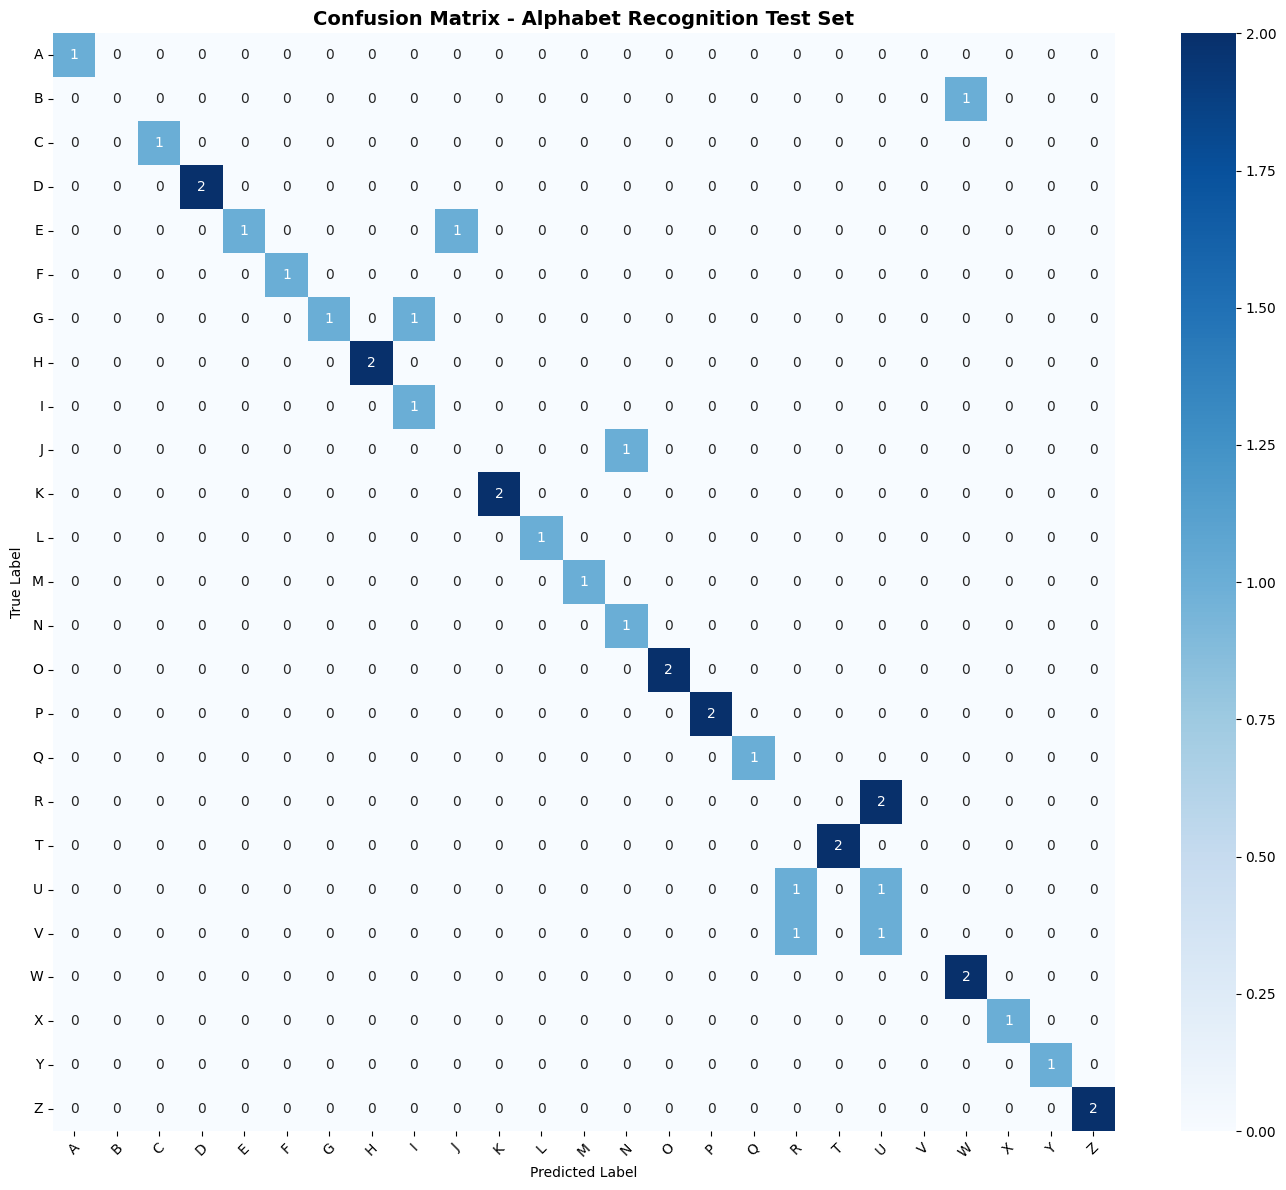

Confusion matrix saved to /kaggle/working/confusion_matrix.png


In [24]:
# Visualize confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Alphabet Recognition Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved to /kaggle/working/confusion_matrix.png")

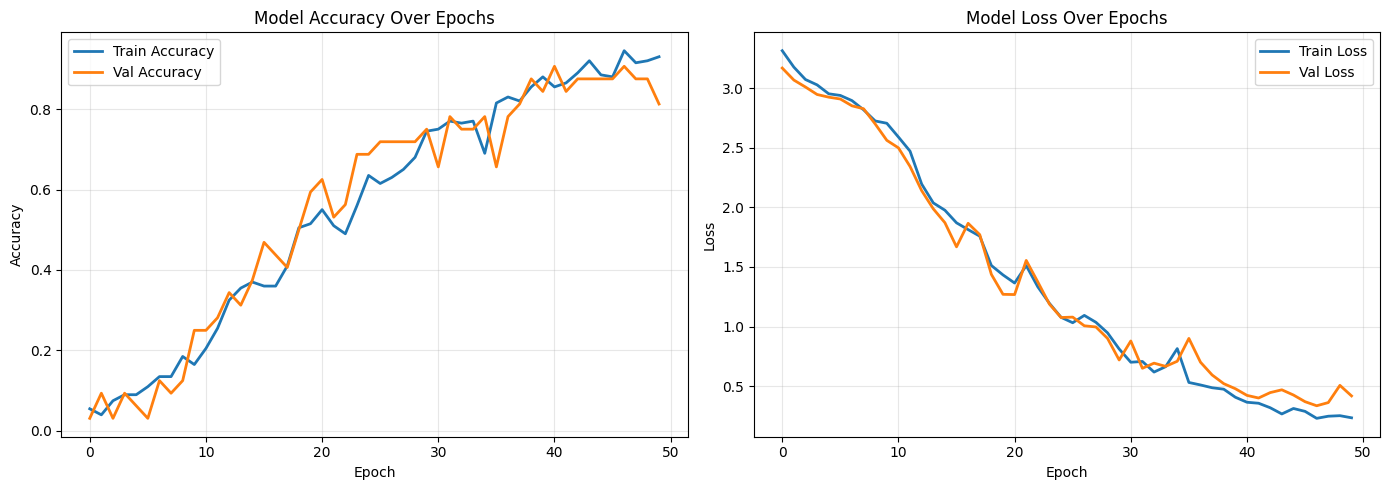

Training history saved to /kaggle/working/training_history.png


In [25]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training history saved to /kaggle/working/training_history.png")

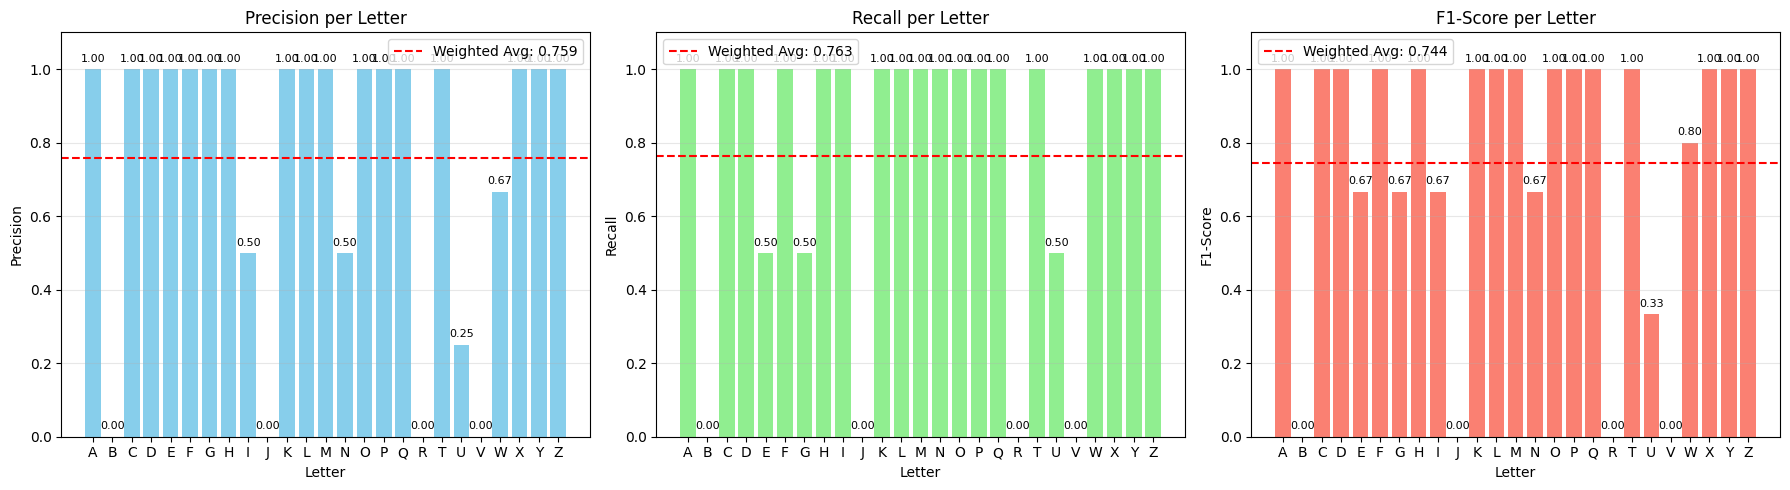

Per-class metrics saved to /kaggle/working/per_class_metrics.png


In [26]:
# Per-class metrics visualization
from sklearn.metrics import precision_recall_fscore_support

precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_test, y_pred, average=None, zero_division=0
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Precision per class
axes[0].bar(class_names, precision_per_class, color='skyblue')
axes[0].set_xlabel('Letter')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision per Letter')
axes[0].set_ylim([0, 1.1])
axes[0].axhline(y=precision, color='r', linestyle='--', label=f'Weighted Avg: {precision:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(precision_per_class):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)

# Recall per class
axes[1].bar(class_names, recall_per_class, color='lightgreen')
axes[1].set_xlabel('Letter')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall per Letter')
axes[1].set_ylim([0, 1.1])
axes[1].axhline(y=recall, color='r', linestyle='--', label=f'Weighted Avg: {recall:.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(recall_per_class):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)

# F1-Score per class
axes[2].bar(class_names, f1_per_class, color='salmon')
axes[2].set_xlabel('Letter')
axes[2].set_ylabel('F1-Score')
axes[2].set_title('F1-Score per Letter')
axes[2].set_ylim([0, 1.1])
axes[2].axhline(y=f1, color='r', linestyle='--', label=f'Weighted Avg: {f1:.3f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(f1_per_class):
    axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Per-class metrics saved to /kaggle/working/per_class_metrics.png")

In [27]:
# Save summary metrics to JSON
metrics_summary = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "weighted_precision": float(precision),
    "weighted_recall": float(recall),
    "weighted_f1_score": float(f1),
    "num_classes": int(num_classes),
    "classes": class_names,
    "test_samples": int(len(y_test)),
    "train_samples_balanced": int(len(X_train_bal)),
    "val_samples": int(len(X_val)),
    "per_class_metrics": {
        class_names[i]: {
            "precision": float(precision_per_class[i]),
            "recall": float(recall_per_class[i]),
            "f1_score": float(f1_per_class[i]),
        }
        for i in range(len(class_names))
    }
}

with open('/kaggle/working/metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print("Metrics summary saved to /kaggle/working/metrics_summary.json")
print("\nMetrics Summary:")
print(json.dumps(metrics_summary, indent=2)[:500] + "...")

Metrics summary saved to /kaggle/working/metrics_summary.json

Metrics Summary:
{
  "test_loss": 0.8217312097549438,
  "test_accuracy": 0.7631579041481018,
  "weighted_precision": 0.7587719298245613,
  "weighted_recall": 0.7631578947368421,
  "weighted_f1_score": 0.743859649122807,
  "num_classes": 25,
  "classes": [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
    "K",
    "L",
    "M",
    "N",
    "O",
    "P",
    "Q",
    "R",
    "T",
    "U",
    "V",
    "W",
    "X",
    "Y",
    "Z"
  ],
  "test_samples": 38,
  "train_s...


In [28]:
# Save label map + export compact TFLite model for real-time inference
label_map = {int(i): c for i, c in enumerate(class_names)}
with open("/kaggle/working/label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)

# Save Keras model artifact
model.save("/kaggle/working/best_asl_alphabet_model.keras")


def convert_to_tflite(keras_model, allow_select_tf_ops=False):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    if allow_select_tf_ops:
        # Needed for some GRU/TensorList graphs
        converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS,
            tf.lite.OpsSet.SELECT_TF_OPS,
        ]
        converter._experimental_lower_tensor_list_ops = False

    return converter.convert()


tflite_path = "/kaggle/working/asl_alphabet_light.tflite"
conversion_mode = "TFLITE_BUILTINS"

try:
    tflite_model = convert_to_tflite(model, allow_select_tf_ops=False)
except Exception as e:
    print("Built-in TFLite conversion failed. Retrying with SELECT_TF_OPS fallback...")
    print("Reason:", str(e)[:500])
    tflite_model = convert_to_tflite(model, allow_select_tf_ops=True)
    conversion_mode = "SELECT_TF_OPS_FALLBACK"

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("\n" + "="*60)
print("SAVED ARTIFACTS")
print("="*60)
print("✓ /kaggle/working/best_asl_alphabet_model.keras")
print("✓ /kaggle/working/asl_alphabet_light.tflite")
print("✓ /kaggle/working/label_map.json")
print("✓ /kaggle/working/metrics_summary.json")
print("✓ /kaggle/working/confusion_matrix.png")
print("✓ /kaggle/working/training_history.png")
print("✓ /kaggle/working/per_class_metrics.png")
print(f"\nTFLite conversion mode: {conversion_mode}")

if conversion_mode == "SELECT_TF_OPS_FALLBACK":
    print(
        "\n⚠️  Note: This TFLite model uses SELECT_TF_OPS (Flex). "
        "For Python inference this is fine; mobile deployment may need Flex support."
    )

INFO:tensorflow:Assets written to: /tmp/tmppsfcvbsr/assets


INFO:tensorflow:Assets written to: /tmp/tmppsfcvbsr/assets


Saved artifact at '/tmp/tmppsfcvbsr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 126), dtype=tf.float32, name='landmarks')
Output Type:
  TensorSpec(shape=(None, 25), dtype=tf.float32, name=None)
Captures:
  140378999635408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378999635792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863435856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863436240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863437584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863436816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863437776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863438544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863437392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863437968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863437008: Ten

W0000 00:00:1779708528.880373      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1779708528.880402      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
loc(callsite(callsite(fused["TensorListReserve:", "asl_alphabet_light_1/gru_1_1/TensorArrayV2_1@__inference_function_31988"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_32051"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): error: 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
loc(callsite(callsite(fused["TensorListReserve:", "asl_alphabet_light_1/gru_1_1/TensorArrayV2_1@__inference_function_31988"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_32051"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): error: failed to legalize operation 'tf.TensorListReserve' that was explicitly marked illegal
error: Lower

Built-in TFLite conversion failed. Retrying with SELECT_TF_OPS fallback...
Reason: <unknown>:0: error: loc(callsite(callsite(fused["TensorListReserve:", "asl_alphabet_light_1/gru_1_1/TensorArrayV2_1@__inference_function_31988"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_32051"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): 
INFO:tensorflow:Assets written to: /tmp/tmp_yi3c6ve/assets


INFO:tensorflow:Assets written to: /tmp/tmp_yi3c6ve/assets


Saved artifact at '/tmp/tmp_yi3c6ve'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 126), dtype=tf.float32, name='landmarks')
Output Type:
  TensorSpec(shape=(None, 25), dtype=tf.float32, name=None)
Captures:
  140378999635408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378999635792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863435856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863436240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863437584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863436816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863437776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863438544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863437392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863437968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140378863437008: Ten

W0000 00:00:1779708529.806046      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1779708529.806092      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.



SAVED ARTIFACTS
✓ /kaggle/working/best_asl_alphabet_model.keras
✓ /kaggle/working/asl_alphabet_light.tflite
✓ /kaggle/working/label_map.json
✓ /kaggle/working/metrics_summary.json
✓ /kaggle/working/confusion_matrix.png
✓ /kaggle/working/training_history.png
✓ /kaggle/working/per_class_metrics.png

TFLite conversion mode: SELECT_TF_OPS_FALLBACK

⚠️  Note: This TFLite model uses SELECT_TF_OPS (Flex). For Python inference this is fine; mobile deployment may need Flex support.
